In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

# Surface a failed install here, rather than as a confusing ModuleNotFoundError
# in the import cell below.
import importlib.metadata as md
assert md.version("nucleus-cdk") == "0.5.0rc2", f"got {md.version('nucleus-cdk')}"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cdk.analysis.cytosol import platereader as pr
# import platereader as pr
# Initialize plotting
pr.plot_setup()

In [3]:
import sys

In [4]:
# !ls bnext/experiments/20251106_labcraft_protein_sweep_01

In [5]:
data = pr.load_platereader_data("data/20251106-191540-cytation5-pure-timecourse-gfp-labcraft-protein-sweep1-biotek-cdk.txt")

platemap = pd.read_csv("data/concentration_key.csv")
# platemap.columns = ["Well", "Mg (mM)", "Ribo (uM)", "T7 (ng/ul)", "Water"]
# platemap["Name"] = "GFP " + platemap["[DNA] (nM)"].astype(str) + " nM"
platemap.rename(columns={'Well ID':"Well"}, inplace=True)
platemap = platemap.fillna(0)
# platemap.columns
sweep_cols= ['Mg_mM', 'Ribo_uM', 'T7poly_ng/ul']
for values, g in platemap.groupby(sweep_cols):
    mg, ribo, T7 = values
    name = f"Mg {mg}; R {ribo}; T7 {T7}"
    platemap.loc[g.index, "Name"] = name

platemap

data = data.merge(platemap)

In [6]:
platemap.head()
data.head()

,Time,Well,Data,Row,Column,Read,Plate,Clock Time,Mg_mM,Ribo_uM,T7poly_ng/ul,Water_--,Name
0,0 days 00:01:09,A1,231,A,1,GFP-Gext,Plate 1,2025-11-06 19:54:11,0.00,0.00,0.00,0.20,Mg 0.0; R 0.0; T7 0.0
1,0 days 00:06:09,A1,237,A,1,GFP-Gext,Plate 1,2025-11-06 19:59:11,0.00,0.00,0.00,0.20,Mg 0.0; R 0.0; T7 0.0
2,0 days 00:11:09,A1,261,A,1,GFP-Gext,Plate 1,2025-11-06 20:04:11,0.00,0.00,0.00,0.20,Mg 0.0; R 0.0; T7 0.0
3,0 days 00:16:09,A1,367,A,1,GFP-Gext,Plate 1,2025-11-06 20:09:11,0.00,0.00,0.00,0.20,Mg 0.0; R 0.0; T7 0.0
4,0 days 00:21:09,A1,949,A,1,GFP-Gext,Plate 1,2025-11-06 20:14:11,0.00,0.00,0.00,0.20,Mg 0.0; R 0.0; T7 0.0


In [7]:
data

,Time,Well,Data,Row,Column,Read,Plate,Clock Time,Mg_mM,Ribo_uM,T7poly_ng/ul,Water_--,Name
0,0 days 00:01:09,A1,231,A,1,GFP-Gext,Plate 1,2025-11-06 19:54:11,0.00,0.00,0.00,0.20,Mg 0.0; R 0.0; T7 0.0
1,0 days 00:06:09,A1,237,A,1,GFP-Gext,Plate 1,2025-11-06 19:59:11,0.00,0.00,0.00,0.20,Mg 0.0; R 0.0; T7 0.0
2,0 days 00:11:09,A1,261,A,1,GFP-Gext,Plate 1,2025-11-06 20:04:11,0.00,0.00,0.00,0.20,Mg 0.0; R 0.0; T7 0.0
3,0 days 00:16:09,A1,367,A,1,GFP-Gext,Plate 1,2025-11-06 20:09:11,0.00,0.00,0.00,0.20,Mg 0.0; R 0.0; T7 0.0
4,0 days 00:21:09,A1,949,A,1,GFP-Gext,Plate 1,2025-11-06 20:14:11,0.00,0.00,0.00,0.20,Mg 0.0; R 0.0; T7 0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7879,0 days 05:41:09,P6,138552,P,6,GFP-Gext,Plate 1,2025-11-07 01:34:11,3.95,0.69,13.38,0.00,Mg 3.9488; R 0.6903; T7 13.383
7880,0 days 05:46:09,P6,138407,P,6,GFP-Gext,Plate 1,2025-11-07 01:39:11,3.95,0.69,13.38,0.00,Mg 3.9488; R 0.6903; T7 13.383
7881,0 days 05:51:09,P6,138297,P,6,GFP-Gext,Plate 1,2025-11-07 01:44:11,3.95,0.69,13.38,0.00,Mg 3.9488; R 0.6903; T7 13.383
7882,0 days 05:56:09,P6,138212,P,6,GFP-Gext,Plate 1,2025-11-07 01:49:11,3.95,0.69,13.38,0.00,Mg 3.9488; R 0.6903; T7 13.383


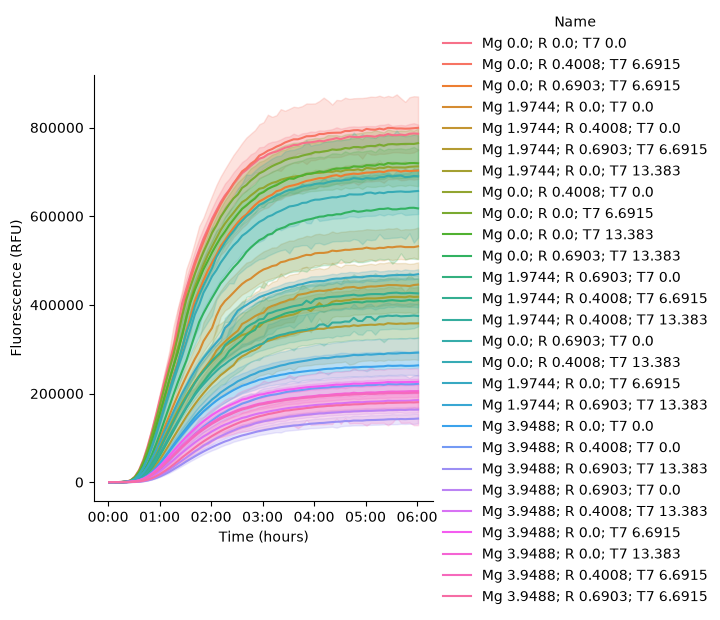

In [8]:
pr.plot_curves(data)

In [9]:
# pr.plot_curves(data, hue=sweep_cols[0], col=sweep_cols[2], palette="viridis")
print(sweep_cols)

['Mg_mM', 'Ribo_uM', 'T7poly_ng/ul']


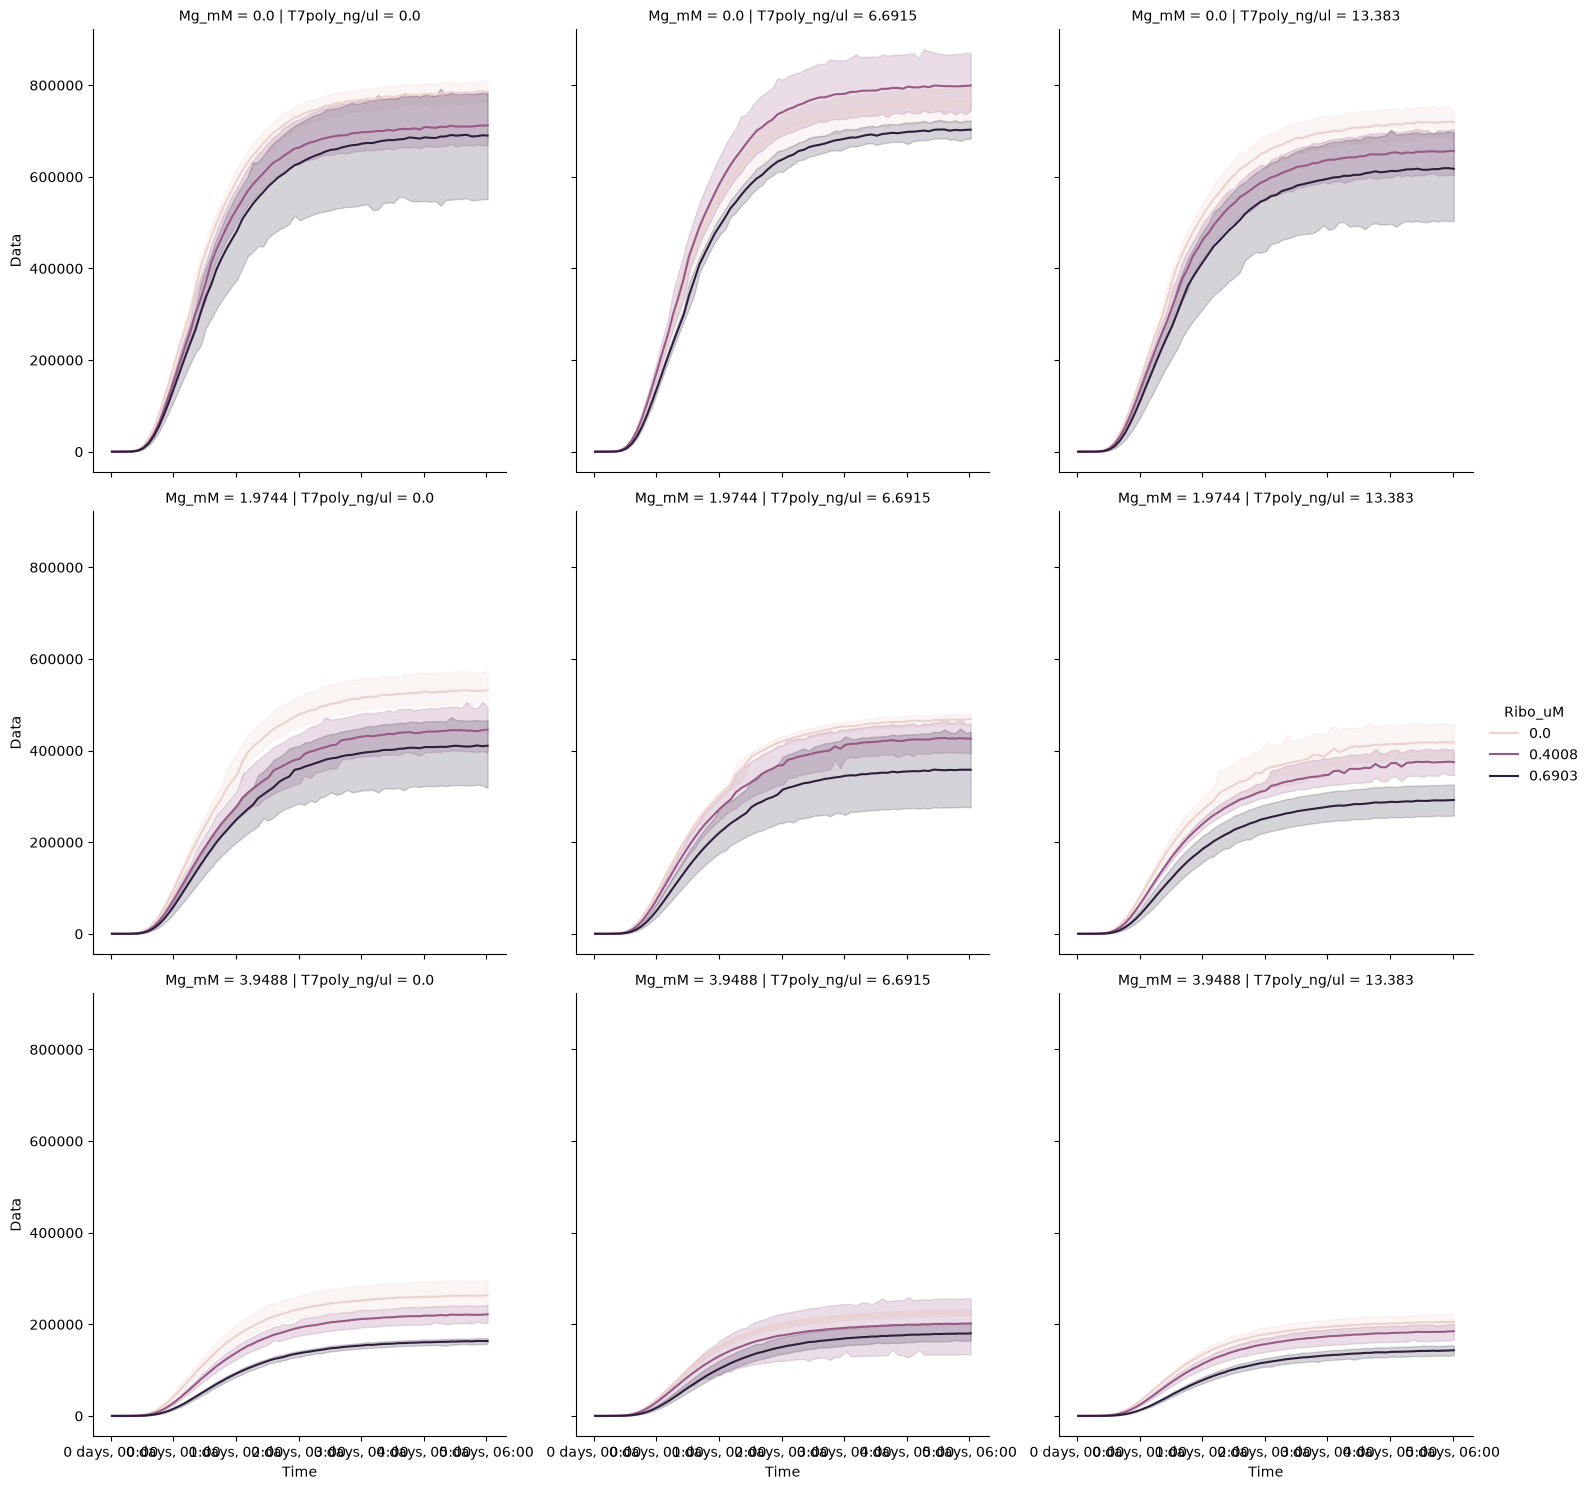

In [10]:
sns.relplot(data, x="Time", y="Data", row=sweep_cols[0], col=sweep_cols[2], hue=sweep_cols[1], kind="line") #, hue="Name")

In [11]:
kinetics = pr.kinetic_analysis(data, group_by=["Name"])
kinetics

/private/tmp/claude-501/-Users-sharonnewman-Documents-general-nucleus-skills/4a8d6065-9e0a-4e14-b326-0bffb6d3273b/scratchpad/cdkenv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/private/tmp/claude-501/-Users-sharonnewman-Documents-general-nucleus-skills/4a8d6065-9e0a-4e14-b326-0bffb6d3273b/scratchpad/cdkenv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


/private/tmp/claude-501/-Users-sharonnewman-Documents-general-nucleus-skills/4a8d6065-9e0a-4e14-b326-0bffb6d3273b/scratchpad/cdkenv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


PROVIDING AVERAGED KINETICS


Velocity                      \
                                                    Time      Data       Max   
Name                                                                           
Mg 0.0; R 0.0; T7 0.0          0 days 01:25:06.384157767 391036.93 464495.78   
Mg 0.0; R 0.0; T7 13.383       0 days 01:23:12.227808558 357873.19 379802.81   
Mg 0.0; R 0.0; T7 6.6915       0 days 01:23:00.991286042 367973.45 427639.32   
Mg 0.0; R 0.4008; T7 0.0       0 days 01:24:07.313832339 356736.31 414825.70   
Mg 0.0; R 0.4008; T7 13.383    0 days 01:25:42.038596308 330913.22 334829.87   
Mg 0.0; R 0.4008; T7 6.6915    0 days 01:23:42.845952033 392106.89 449012.30   
Mg 0.0; R 0.6903; T7 0.0       0 days 01:29:55.710262378 340358.30 372208.22   
Mg 0.0; R 0.6903; T7 13.383    0 days 01:30:56.793676442 310808.77 303268.05   
Mg 0.0; R 0.6903; T7 6.6915    0 days 01:26:35.570398910 355678.24 362781.19   
Mg 1.9744; R 0.0; T7 0.0       0 days 01:31:10.047957710 266026.68 265537.28   
Mg 1.9744; R 0.0; T7 13.383    0 days 01:22:38.831052047 209776.90 181448.51   
Mg 1.9744; R 0.0; T7 6.6915    0 days 01:29:22.965593733 234582.15 223475.76   
Mg 1.9744; R 0.4008; T7 0.0    0 days 01:32:26.433102526 223002.30 199158.18   
Mg 1.9744; R 0.4008; T7 13.383 0 days 01:24:06.960227581 188265.56 158092.24   
Mg 1.9744; R 0.4008; T7 6.6915 0 days 01:29:32.494454971 214017.22 191450.93   
Mg 1.9744; R 0.6903; T7 0.0    0 days 01:37:11.559421711 205806.38 185203.77   
Mg 1.9744; R 0.6903; T7 13.383 0 days 01:33:27.475317193 146055.89 134875.18   
Mg 1.9744; R 0.6903; T7 6.6915 0 days 01:35:55.723313741 179588.56 163286.65   
Mg 3.9488; R 0.0; T7 0.0       0 days 01:30:38.899218105 131767.15 129933.86   
Mg 3.9488; R 0.0; T7 13.383    0 days 01:29:35.896920936 102768.54  96198.01   
Mg 3.9488; R 0.0; T7 6.6915    0 days 01:29:18.900008816 113198.80 109991.03   
Mg 3.9488; R 0.4008; T7 0.0    0 days 01:36:19.162132231 110818.63 104481.71   
Mg 3.9488; R 0.4008; T7 13.383 0 days 01:34:15.104488488  92453.17  81578.59   
Mg 3.9488; R 0.4008; T7 6.6915 0 days 01:30:49.317234001 100944.78  96721.92   
Mg 3.9488; R 0.6903; T7 0.0    0 days 01:44:19.124703433  81955.51  71528.78   
Mg 3.9488; R 0.6903; T7 13.383 0 days 01:45:24.189728286  67605.95  59776.16   
Mg 3.9488; R 0.6903; T7 6.6915 0 days 01:42:58.014040578  90240.65  78414.00   

                                                     Lag            \
                                                    Time      Data   
Name                                                                 
Mg 0.0; R 0.0; T7 0.0          0 days 00:34:29.416211466  58273.39   
Mg 0.0; R 0.0; T7 13.383       0 days 00:26:26.200437412  15446.97   
Mg 0.0; R 0.0; T7 6.6915       0 days 00:31:07.936658955  36882.12   
Mg 0.0; R 0.4008; T7 0.0       0 days 00:32:35.902041874  30788.26   
Mg 0.0; R 0.4008; T7 13.383    0 days 00:26:29.008152804  11516.61   
Mg 0.0; R 0.4008; T7 6.6915    0 days 00:31:18.592564633  33526.11   
Mg 0.0; R 0.6903; T7 0.0       0 days 00:34:46.926552948  42570.22   
Mg 0.0; R 0.6903; T7 13.383    0 days 00:29:02.185712247  12702.54   
Mg 0.0; R 0.6903; T7 6.6915    0 days 00:27:44.533647051  15200.72   
Mg 1.9744; R 0.0; T7 0.0       0 days 00:30:54.371716438  18549.69   
Mg 1.9744; R 0.0; T7 13.383    0 days 00:12:12.048795450 -13817.18   
Mg 1.9744; R 0.0; T7 6.6915    0 days 00:26:20.096878108  10803.28   
Mg 1.9744; R 0.4008; T7 0.0    0 days 00:24:19.111957006   5599.48   
Mg 1.9744; R 0.4008; T7 13.383 0 days 00:12:14.443602857 -15926.72   
Mg 1.9744; R 0.4008; T7 6.6915 0 days 00:21:36.523796879   1314.50   
Mg 1.9744; R 0.6903; T7 0.0    0 days 00:30:38.184571957  10962.55   
Mg 1.9744; R 0.6903; T7 13.383 0 days 00:28:23.405745736   3120.04   
Mg 1.9744; R 0.6903; T7 6.6915 0 days 00:30:22.672605073   8290.13   
Mg 3.9488; R 0.0; T7 0.0       0 days 00:29:43.509092187   5846.39   
Mg 3.9488; R 0.0; T7 13.383    0 days 00:25:27.577661245   1195.47   
Mg 3.9488; R 0.0; T7 6.6915    0 days

In [12]:
kinetics.columns
ss = kinetics["Steady State"]["Data"].reset_index().merge(platemap)
# ss = kinetics["Velocity"]["Max"].reset_index().merge(platemap)

# data_name = 'Max' #Data
data_name = 'Data'

/private/tmp/claude-501/-Users-sharonnewman-Documents-general-nucleus-skills/4a8d6065-9e0a-4e14-b326-0bffb6d3273b/scratchpad/cdkenv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/private/tmp/claude-501/-Users-sharonnewman-Documents-general-nucleus-skills/4a8d6065-9e0a-4e14-b326-0bffb6d3273b/scratchpad/cdkenv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


/private/tmp/claude-501/-Users-sharonnewman-Documents-general-nucleus-skills/4a8d6065-9e0a-4e14-b326-0bffb6d3273b/scratchpad/cdkenv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x112f36f00>,
                                                 Velocity                      \
                                                     Time      Data       Max   
 Name                                                                           
 Mg 0.0; R 0.0; T7 0.0          0 days 01:25:06.384157767 391036.93 464495.78   
 Mg 0.0; R 0.0; T7 13.383       0 days 01:23:12.227808558 357873.19 379802.81   
 Mg 0.0; R 0.0; T7 6.6915       0 days 01:23:00.991286042 367973.45 427639.32   
 Mg 0.0; R 0.4008; T7 0.0       0 days 01:24:07.313832339 356736.31 414825.70   
 Mg 0.0; R 0.4008; T7 13.383    0 days 01:25:42.038596308 330913.22 334829.87   
 Mg 0.0; R 0.4008; T7 6.6915    0 days 01:23:42.845952033 392106.89 449012.30   
 Mg 0.0; R 0.6903; T7 0.0       0 days 01:29:55.710262378 340358.30 372208.22   
 Mg 0.0; R 0.6903; T7 13.383    0 days 01:30:56.793676442 310808.77 303268.05   
 Mg 0.0; R 0.6903; T7 6.6915    0 days 01:26:35.570398910 35567

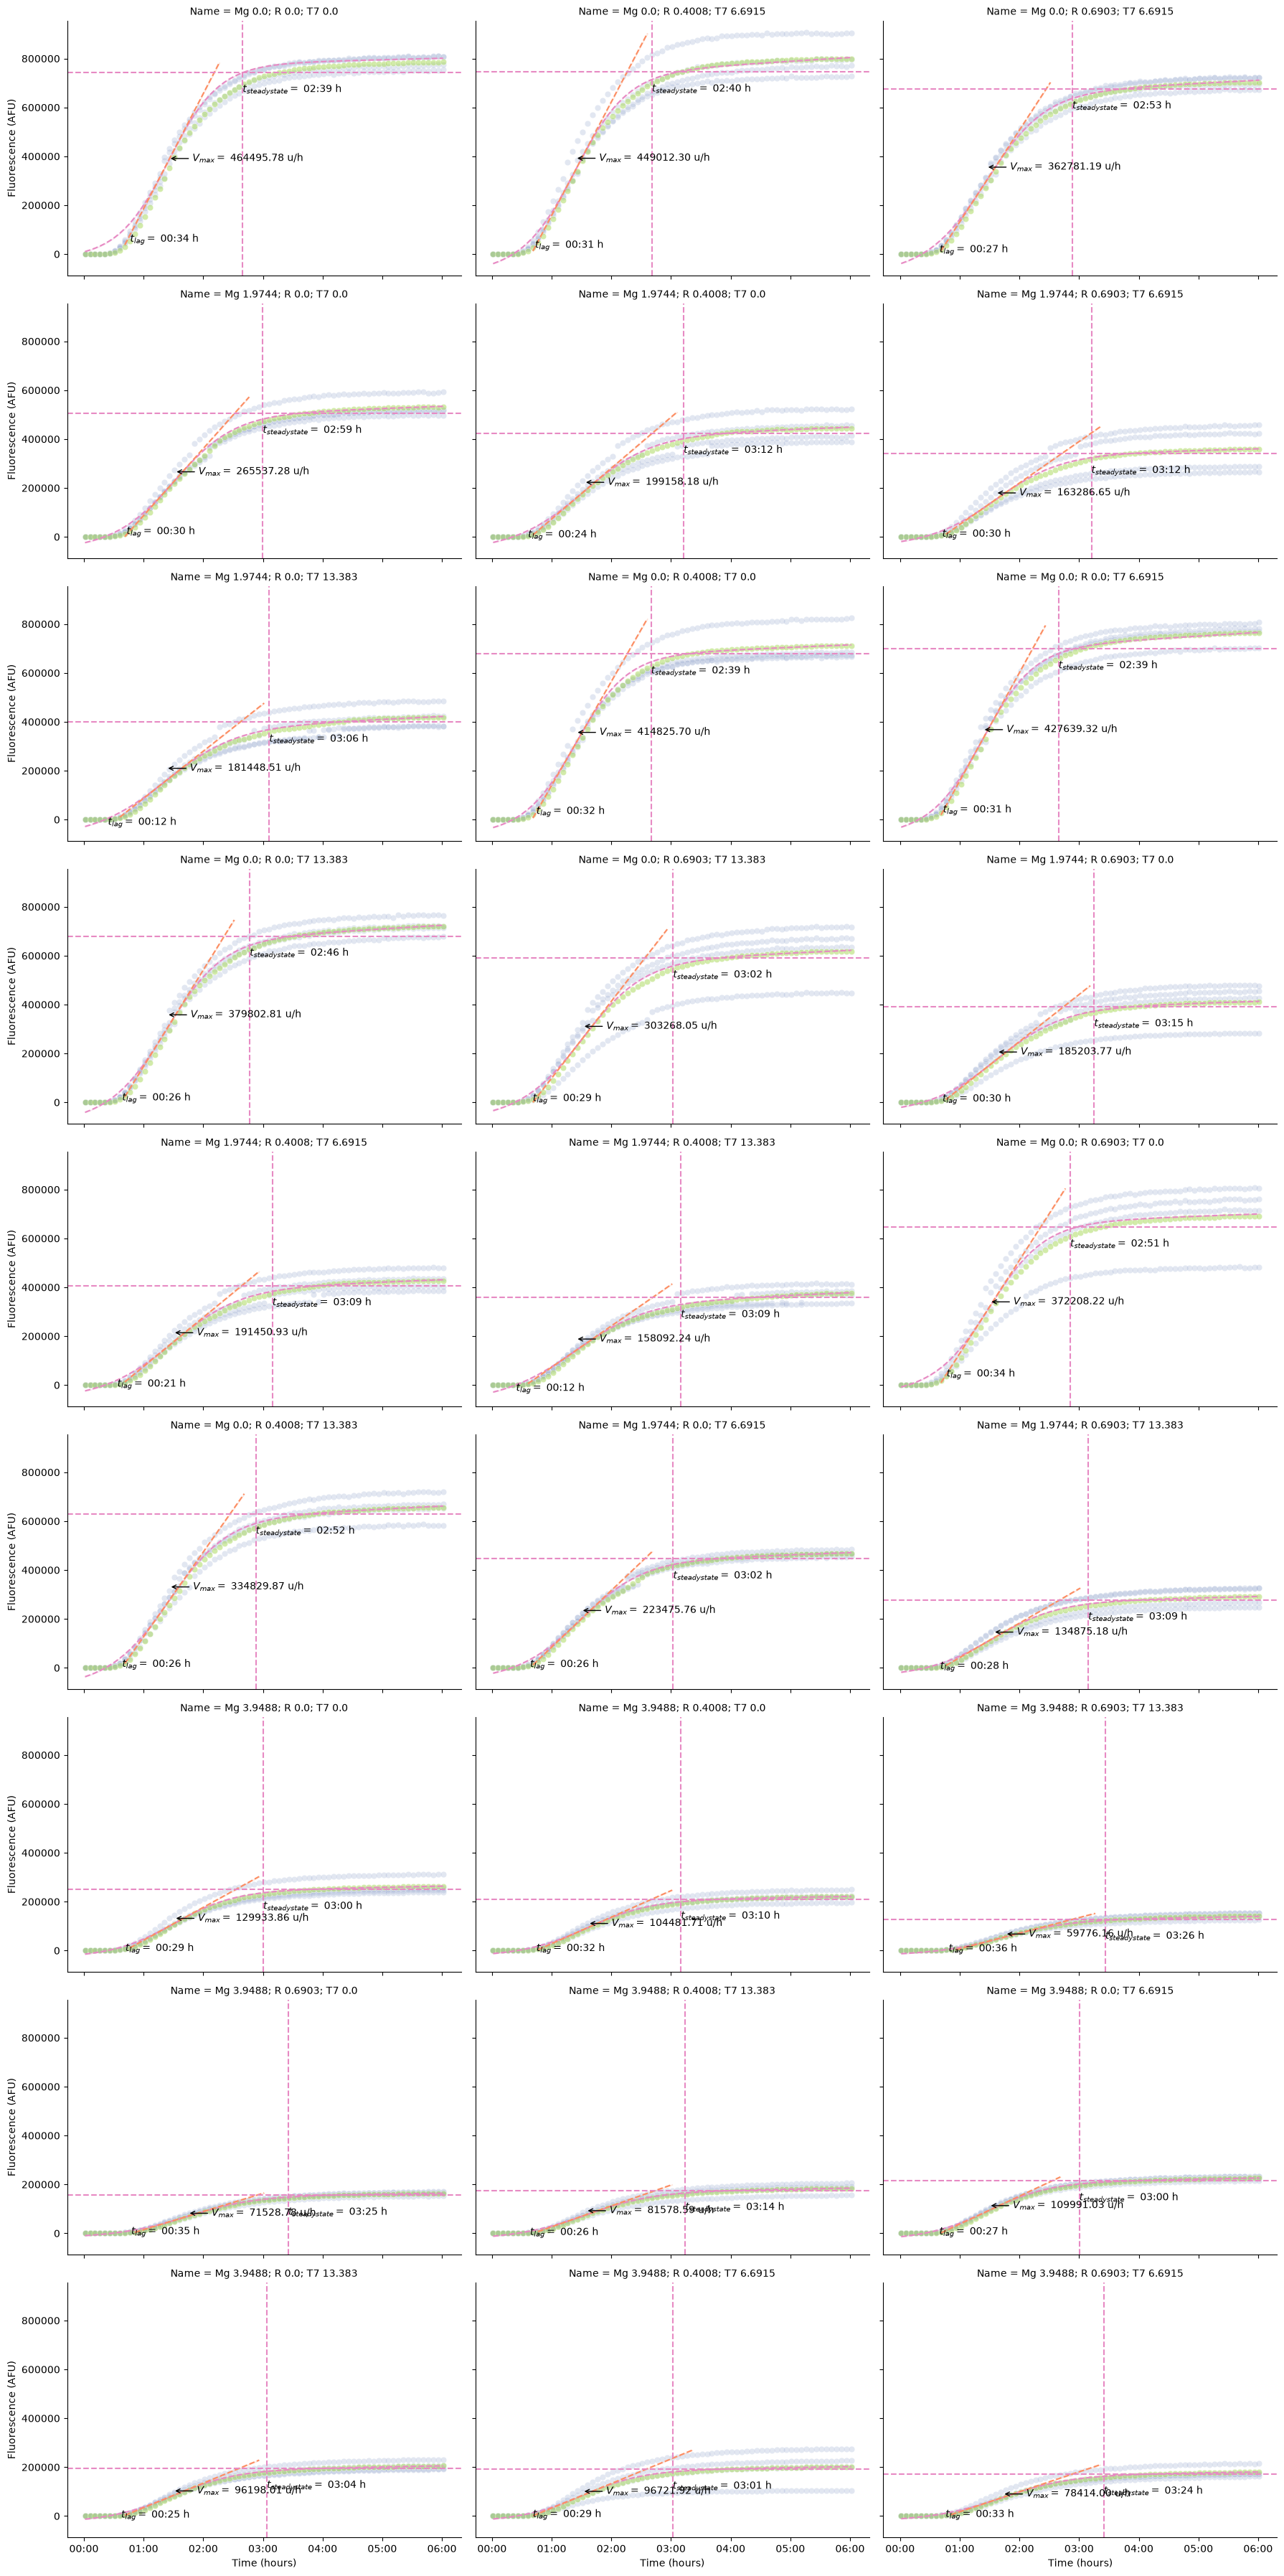

In [13]:
pr.plot_kinetics(data, group_by=["Name"])

In [14]:
ss.head()

,Name,Data,Well,Mg_mM,Ribo_uM,T7poly_ng/ul,Water_--
0,Mg 0.0; R 0.0; T7 0.0,742970.17,A1,0.00,0.00,0.00,0.20
1,Mg 0.0; R 0.0; T7 0.0,742970.17,E2,0.00,0.00,0.00,0.20
2,Mg 0.0; R 0.0; T7 0.0,742970.17,J4,0.00,0.00,0.00,0.20
3,Mg 0.0; R 0.0; T7 0.0,742970.17,O6,0.00,0.00,0.00,0.20
4,Mg 0.0; R 0.0; T7 13.383,679959.06,B3,0.00,0.00,13.38,0.16


In [15]:
ss.to_csv('steady_states.csv', index=False)

/var/folders/4l/5bp8d9ks6v15tkhzpbszxxpc0000gn/T/ipykernel_21493/806804362.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for color bar


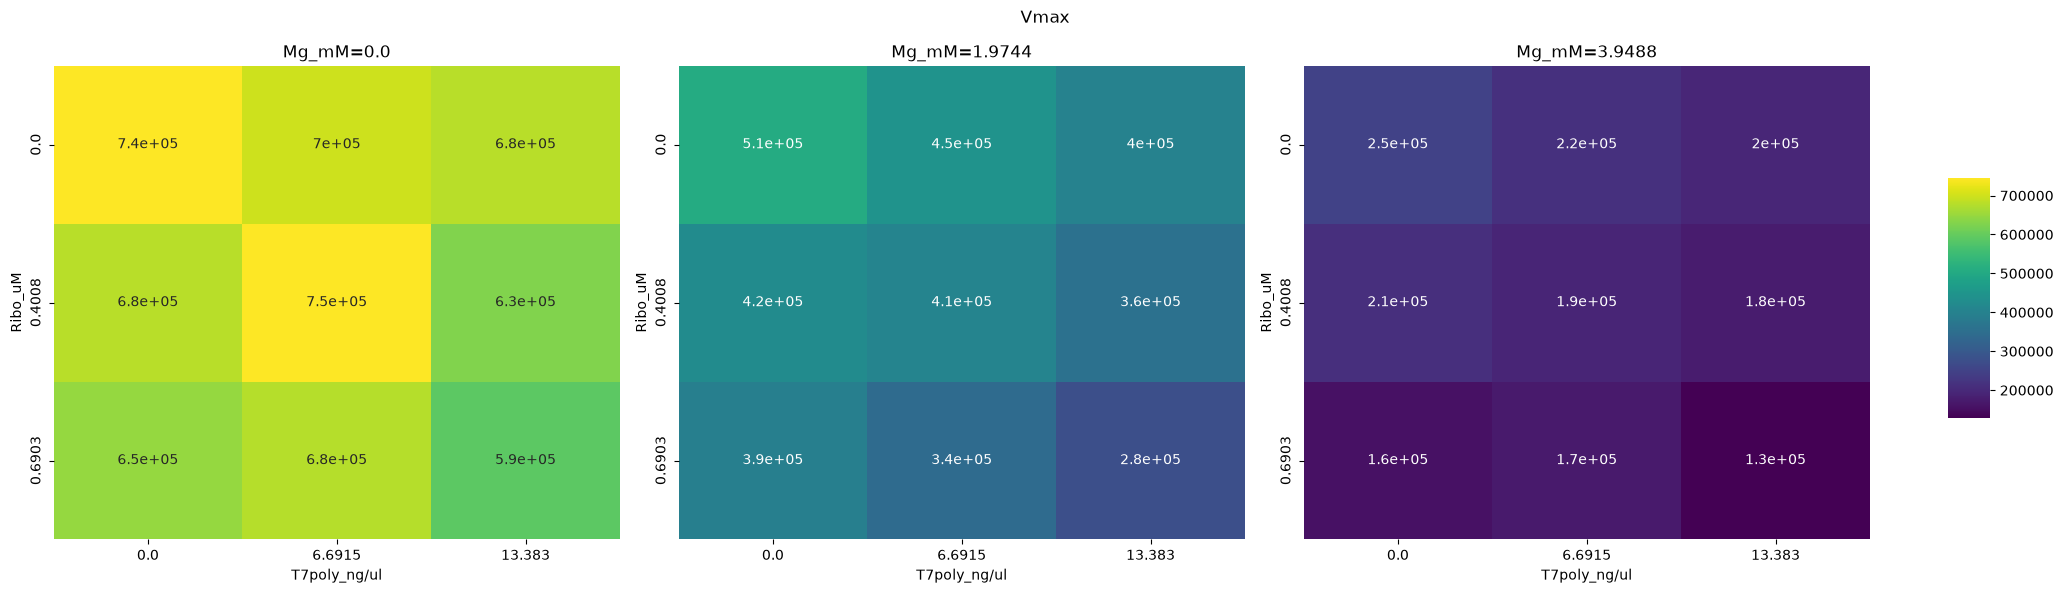

In [16]:
df = ss

# Average replicates
means = df.groupby(['Mg_mM', 'Ribo_uM', 'T7poly_ng/ul'], as_index=False)[data_name].mean()

# Global min/max for shared color bar
data_min = means[data_name].min()
data_max = means[data_name].max()

t7_values = means['Mg_mM'].unique()
n_plots = len(t7_values)
fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 6), squeeze=False)

for idx, t7 in enumerate(sorted(t7_values)):
    slice_df = means[means['Mg_mM'] == t7]
    pivot = slice_df.pivot(index='Ribo_uM', columns='T7poly_ng/ul', values=data_name)
    ax = axes[0, idx]
    hm = sns.heatmap(
        pivot, annot=True, cmap='viridis',
        vmin=data_min, vmax=data_max,  # shared color scale
        cbar=idx==n_plots-1, cbar_ax=None if idx < n_plots-1 else plt.gcf().add_axes([0.93, 0.3, 0.02, 0.4]),
        ax=ax
    )
    ax.set_title(f'Mg_mM={t7}')
    ax.set_xlabel('T7poly_ng/ul')
    ax.set_ylabel('Ribo_uM')

plt.suptitle("Vmax")
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for color bar
plt.show()

/var/folders/4l/5bp8d9ks6v15tkhzpbszxxpc0000gn/T/ipykernel_21493/2296589567.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for color bar


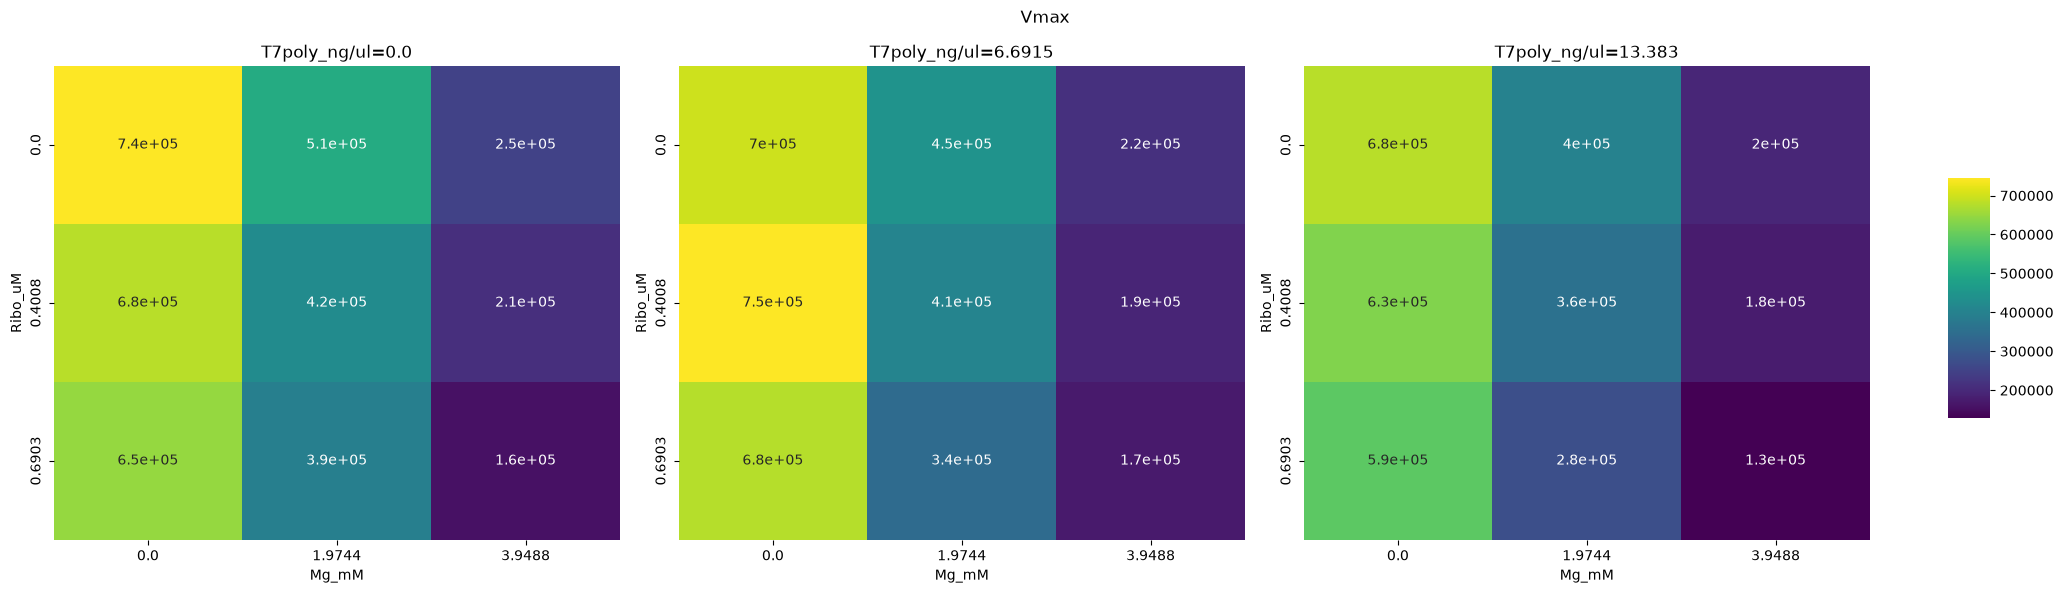

In [17]:
df = ss
# Average replicates
means = df.groupby(['Mg_mM', 'Ribo_uM', 'T7poly_ng/ul'], as_index=False)[data_name].mean()

# Global min/max for shared color bar
data_min = means[data_name].min()
data_max = means[data_name].max()

t7_values = means['T7poly_ng/ul'].unique()
n_plots = len(t7_values)
fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 6), squeeze=False)

for idx, t7 in enumerate(sorted(t7_values)):
    slice_df = means[means['T7poly_ng/ul'] == t7]
    pivot = slice_df.pivot(index='Ribo_uM', columns='Mg_mM', values=data_name)
    ax = axes[0, idx]
    hm = sns.heatmap(
        pivot, annot=True, cmap='viridis',
        vmin=data_min, vmax=data_max,  # shared color scale
        cbar=idx==n_plots-1, cbar_ax=None if idx < n_plots-1 else plt.gcf().add_axes([0.93, 0.3, 0.02, 0.4]),
        ax=ax
    )
    ax.set_title(f'T7poly_ng/ul={t7}')
    ax.set_xlabel('Mg_mM')
    ax.set_ylabel('Ribo_uM')

plt.suptitle("Vmax")
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for color bar
plt.show()

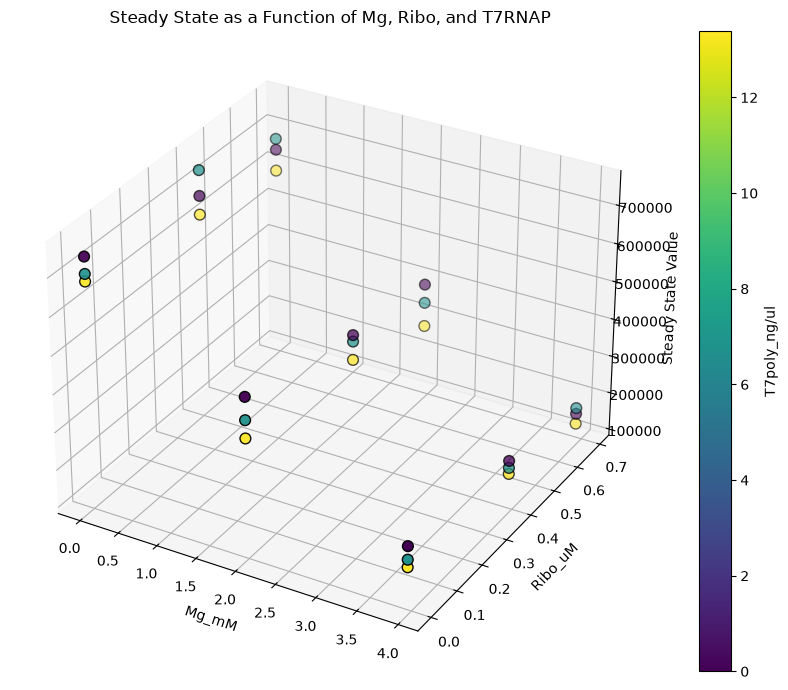

In [18]:
# data_name = 'Max' #Data
# Average replicates
means = df.groupby(['Mg_mM', 'Ribo_uM', 'T7poly_ng/ul'], as_index=False)[data_name].mean()

# 3D scatter/Surface for each unique T7poly_ng/ul, or all together using T7poly as color:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Normalize T7poly for color mapping
norm = plt.Normalize(means['T7poly_ng/ul'].min(), means['T7poly_ng/ul'].max())
colors = plt.cm.viridis(norm(means['T7poly_ng/ul']))

scat = ax.scatter(means['Mg_mM'], means['Ribo_uM'], means[data_name],
                  c=colors, s=60, edgecolor='k')

# Add colorbar for T7poly_ng/ul
mappable = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
mappable.set_array(means['T7poly_ng/ul'])
fig.colorbar(mappable, ax=ax, label='T7poly_ng/ul')

ax.set_xlabel('Mg_mM')
ax.set_ylabel('Ribo_uM')
ax.set_zlabel('Steady State Value')
ax.set_title('Steady State as a Function of Mg, Ribo, and T7RNAP')

plt.tight_layout()
plt.show()

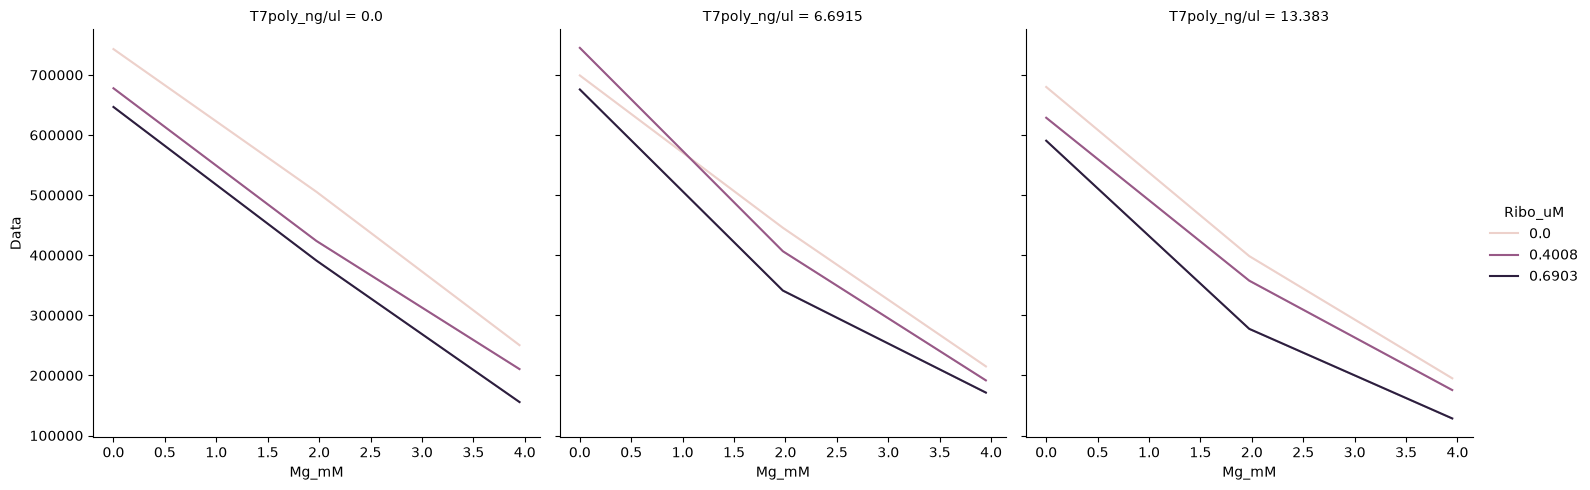

In [19]:
# Build a continuous palette for Ribo
norm = plt.Normalize(df['Ribo_uM'].min(), df['Ribo_uM'].max())
cmap = plt.cm.viridis

g = sns.relplot(
    data=df,
    x="Mg_mM", y="Data",
    col="T7poly_ng/ul", hue="Ribo_uM",  err_style='band', errorbar='sd',
    kind="line",
    facet_kws={'sharey': True, 'sharex': True},
    hue_norm=(df['Ribo_uM'].min(), df['Ribo_uM'].max())
)

In [20]:
df.columns

Index(['Name', 'Data', 'Well', 'Mg_mM', 'Ribo_uM', 'T7poly_ng/ul', 'Water_--'], dtype='object')

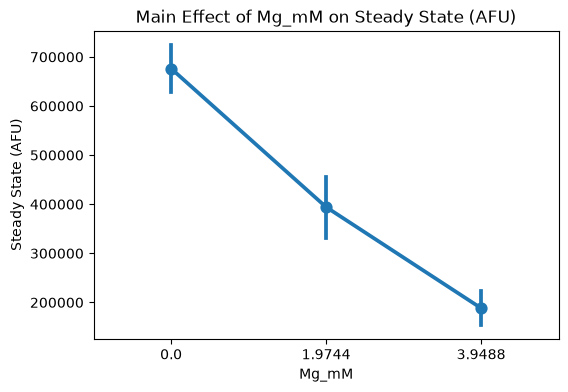

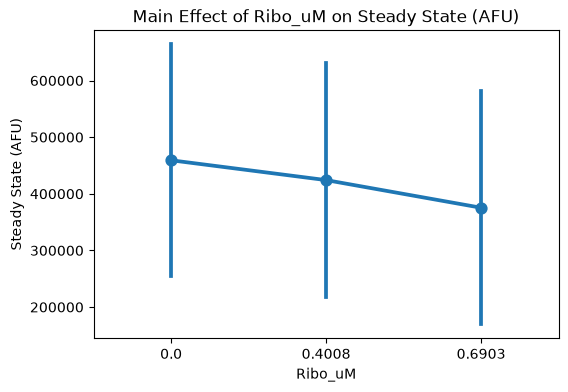

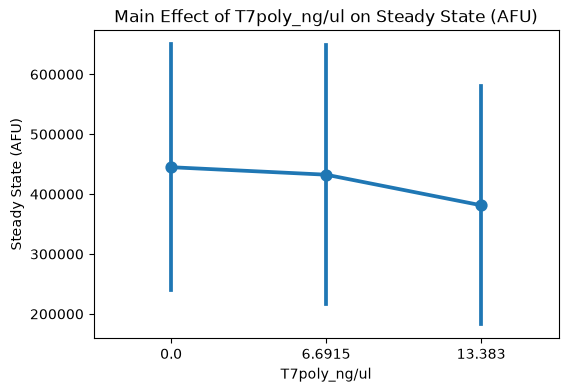

In [21]:
def plot_main_effects(data, response_var):
    # Get all columns except the response variable
    factors = [col for col in data.columns if col != response_var]
    
    # Plot each factor's main effect
    for factor in factors:
        plt.figure(figsize=(6, 4))
        sns.pointplot(x=factor, y=response_var, data=data, errorbar="sd", markers="o", linestyles="-")
        plt.title(f"Main Effect of {factor} on {response_var}")
        plt.xlabel(factor)
        plt.ylabel(response_var)
        plt.show()
df["Steady State (AFU)"] = df["Data"]
plot_main_effects(df[['Steady State (AFU)', 'Mg_mM', 'Ribo_uM', 'T7poly_ng/ul']], "Steady State (AFU)")

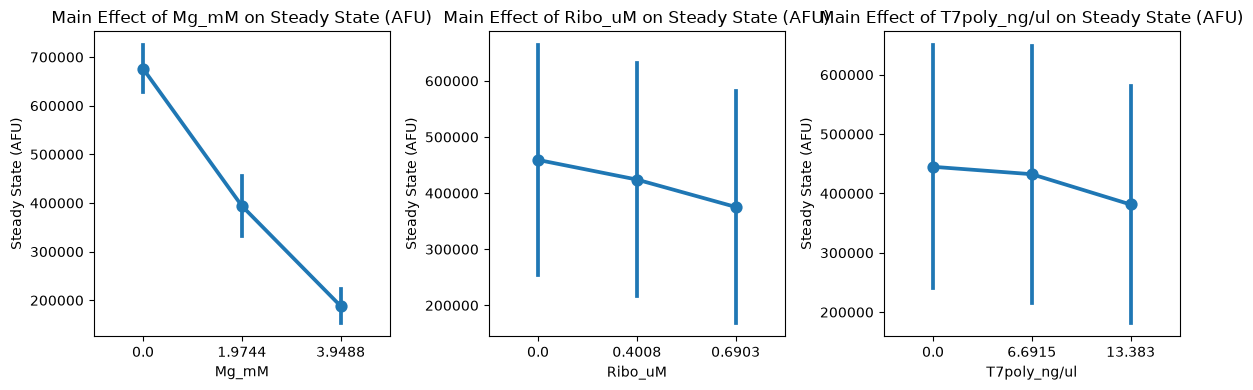

In [22]:
import math
def plot_main_effects(data, response_var):
    # Get all columns except the response variable
    factors = [col for col in data.columns if col != response_var]
    n = len(factors)

    # Determine subplot grid size
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten()  # flatten in case of 1 row

    for ax, factor in zip(axes, factors):
        sns.pointplot(
            x=factor,
            y=response_var,
            data=data,
            errorbar="sd",
            markers="o",
            linestyles="-",
            ax=ax
        )
        ax.set_title(f"Main Effect of {factor} on {response_var}")
        ax.set_xlabel(factor)
        ax.set_ylabel(response_var)

    # Hide any empty subplots
    for i in range(len(factors), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

df["Steady State (AFU)"] = df["Data"]
plot_main_effects(df[['Steady State (AFU)', 'Mg_mM', 'Ribo_uM', 'T7poly_ng/ul']], "Steady State (AFU)")

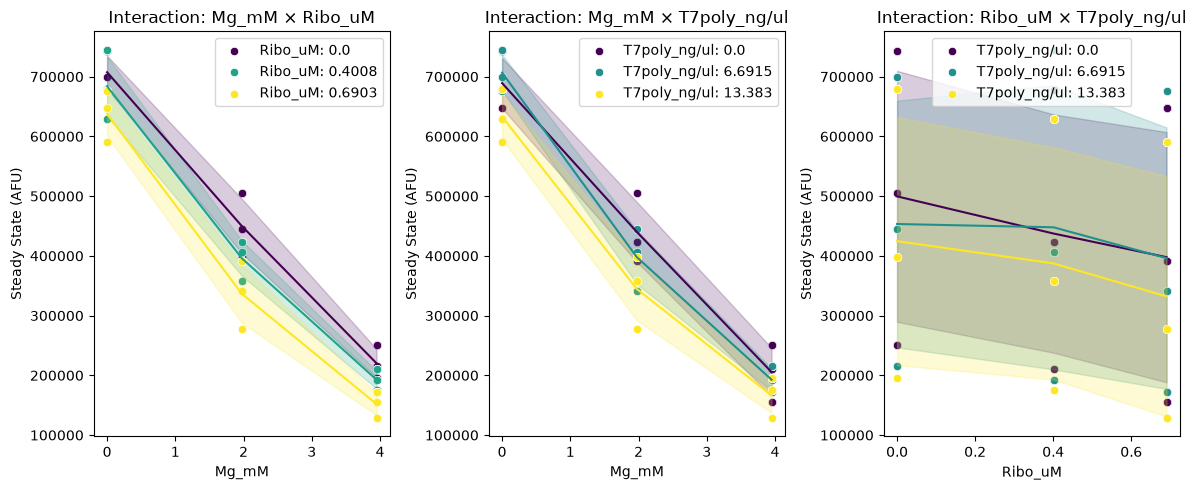

In [23]:
import numpy as np
from itertools import combinations
def plot_all_interactions(data, response_var):
    factors = [col for col in data.columns if col != response_var]
    factor_pairs = list(combinations(factors, 2))
    n = len(factor_pairs)

    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    axes = axes.flatten()

    for ax, (factor_x, factor_hue) in zip(axes, factor_pairs):

        levels = np.sort(data[factor_hue].unique())

        # Build a continuous colormap (viridis is great for continuous data)
        cmap = sns.color_palette("viridis", as_cmap=True)

        # Normalize hue values to [0,1] for colormap mapping
        if np.issubdtype(data[factor_hue].dtype, np.number):
            norm_levels = (levels - levels.min()) / (levels.max() - levels.min() + 1e-9)
        else:
            # For categorical: evenly spaced colors
            norm_levels = np.linspace(0, 1, len(levels))

        color_map = {level: cmap(norm) for level, norm in zip(levels, norm_levels)}

        # Plot per hue level
        for level in levels:
            subset = data[data[factor_hue] == level]

            # Scatter points
            sns.scatterplot(
                data=subset,
                x=factor_x,
                y=response_var,
                ax=ax,
                color=color_map[level],
                label=f"{factor_hue}: {level}"
            )

            # CI-smoothed line, same color
            sns.lineplot(
                data=subset,
                x=factor_x,
                y=response_var,
                ax=ax,
                color=color_map[level],
                errorbar="sd"
            )

        ax.set_title(f"Interaction: {factor_x} × {factor_hue}")
        ax.set_xlabel(factor_x)
        ax.set_ylabel(response_var)

    # Hide unused axes
    for i in range(len(factor_pairs), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_all_interactions(df[['Steady State (AFU)', 'Mg_mM', 'Ribo_uM', 'T7poly_ng/ul']], "Steady State (AFU)")
